In [177]:
import pandas as pd
import numpy as np


In [178]:
df = pd.read_csv("Churn_Modelling.csv")

In [179]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [180]:
df.shape

(10000, 14)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [182]:
df.duplicated().sum()

np.int64(0)

In [183]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [184]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [185]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [186]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [187]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [188]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True) #One Hot Encoding

In [189]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [190]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [191]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [192]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [193]:
X_train_scaled

array([[-0.30596744, -0.47585516,  1.02432015, ..., -0.58235407,
         1.73610172,  0.9111777 ],
       [ 1.29521265,  0.00258357,  1.02432015, ..., -0.58235407,
        -0.57600312,  0.9111777 ],
       [-1.54559073, -0.47585516, -0.69860176, ..., -0.58235407,
        -0.57600312, -1.09748077],
       ...,
       [ 0.95431624, -1.33704489,  0.33515138, ..., -0.58235407,
         1.73610172,  0.9111777 ],
       [-2.34101567, -0.47585516,  0.67973577, ..., -0.58235407,
         1.73610172,  0.9111777 ],
       [-1.02908102,  0.28964681, -1.04318614, ..., -0.58235407,
        -0.57600312,  0.9111777 ]], shape=(8000, 11))

In [194]:
import tensorflow as tf
from tensorflow import keras

In [195]:
model = keras.Sequential()

model.add(keras.layers.Dense(20,activation='relu',input_dim=11))
model.add(keras.layers.Dense(8,activation='relu'))
model.add(keras.layers.Dense(3,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

c:\Users\yx084\OneDrive\Python-Modules\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [196]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439 (1.71 KB)

 Trainable params: 439 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

In [197]:
model.compile(loss='binary_crossentropy', optimizer='Adam',metrics=['accuracy'])

In [198]:
history = model.fit(X_train_scaled,y_train,epochs=50,validation_split=0.2)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7684 - loss: 0.5145 - val_accuracy: 0.8050 - val_loss: 0.4452
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8055 - loss: 0.4445 - val_accuracy: 0.8144 - val_loss: 0.4148
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8114 - loss: 0.4230 - val_accuracy: 0.8194 - val_loss: 0.3964
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8259 - loss: 0.4047 - val_accuracy: 0.8456 - val_loss: 0.3738
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8381 - loss: 0.3853 - val_accuracy: 0.8525 - val_loss: 0.3553
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8439 - loss: 0.3705 - val_accuracy: 0.8581 - val_loss: 0.3485
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8494 - loss: 0.3602 - val_accuracy: 0.8581 - val_loss: 0.3413
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8514 - loss: 0.3540 - val_accuracy: 0.

In [199]:
model.layers[1].get_weights()

[array([[-3.74550112e-02,  1.55541733e-01, -4.81420159e-01,
          5.67373872e-01,  3.83391678e-02,  2.98597157e-01,
          2.44710878e-01, -4.25466746e-01],
        [-2.97459364e-01, -2.27882564e-01,  4.61139828e-01,
         -4.81703341e-01,  4.03354257e-01, -2.28862152e-01,
         -5.58865964e-01, -4.91236955e-01],
        [ 3.11708242e-01, -3.51024121e-01,  3.49464923e-01,
          1.54099643e-01,  2.45731369e-01, -1.28750920e-01,
         -5.12717187e-01,  2.10618470e-02],
        [ 1.50001824e-01, -7.56089270e-01, -2.97686547e-01,
          8.35276604e-01, -1.68238744e-01, -8.46746936e-02,
         -3.49566013e-01, -7.47560710e-02],
        [ 5.56588769e-02, -1.72031447e-01, -2.07530692e-01,
          3.02589476e-01, -2.70924777e-01, -1.41988605e-01,
         -3.52292992e-02, -2.72861183e-01],
        [ 4.58317250e-01, -4.69682775e-02,  2.71321118e-01,
          3.86307836e-02,  2.03288019e-01,  1.89859867e-01,
          1.98398456e-01,  3.97758842e-01],
        [-1.9372

In [200]:
y_predicted = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [201]:
#threshold 0.5
y_predicted = np.where(y_predicted>0.5,1,0)

In [202]:
y_predicted

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [203]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predicted)

0.854

In [204]:
import matplotlib.pyplot as plt

In [205]:
history.history

{'accuracy': [0.7684375047683716,
  0.805468738079071,
  0.8114062547683716,
  0.8259375095367432,
  0.8381249904632568,
  0.8439062237739563,
  0.8493750095367432,
  0.8514062762260437,
  0.8550000190734863,
  0.854687511920929,
  0.8567187786102295,
  0.8587499856948853,
  0.8606250286102295,
  0.8592187762260437,
  0.8612499833106995,
  0.8650000095367432,
  0.8628125190734863,
  0.8653125166893005,
  0.8639062643051147,
  0.8646875023841858,
  0.8653125166893005,
  0.8653125166893005,
  0.8673437237739563,
  0.8645312786102295,
  0.8651562333106995,
  0.8642187714576721,
  0.8659374713897705,
  0.8656250238418579,
  0.8657812476158142,
  0.867968738079071,
  0.8673437237739563,
  0.8659374713897705,
  0.8676562309265137,
  0.8678125143051147,
  0.867968738079071,
  0.8687499761581421,
  0.8681250214576721,
  0.8682812452316284,
  0.8675000071525574,
  0.8704687356948853,
  0.8695312738418579,
  0.8707812428474426,
  0.8692187666893005,
  0.8692187666893005,
  0.8698437213897705,
  

In [206]:
history.history['loss']

[0.5144776105880737,
 0.44448575377464294,
 0.4229542911052704,
 0.40470412373542786,
 0.38525769114494324,
 0.3704870939254761,
 0.3602426052093506,
 0.3539698123931885,
 0.34863197803497314,
 0.344940185546875,
 0.3417375087738037,
 0.3385460376739502,
 0.3365173041820526,
 0.3343154788017273,
 0.33309462666511536,
 0.33121153712272644,
 0.3296228349208832,
 0.32891449332237244,
 0.3283537030220032,
 0.3267021179199219,
 0.3263806998729706,
 0.32501277327537537,
 0.3241100609302521,
 0.3238495886325836,
 0.32310113310813904,
 0.32255664467811584,
 0.3222735524177551,
 0.32160747051239014,
 0.32096928358078003,
 0.31978920102119446,
 0.31868037581443787,
 0.31900957226753235,
 0.318779319524765,
 0.31891676783561707,
 0.3184076249599457,
 0.31774574518203735,
 0.3175131678581238,
 0.31666746735572815,
 0.31696319580078125,
 0.3161315321922302,
 0.3162057399749756,
 0.31573134660720825,
 0.3154293894767761,
 0.31449517607688904,
 0.31429630517959595,
 0.3135187029838562,
 0.31360438466

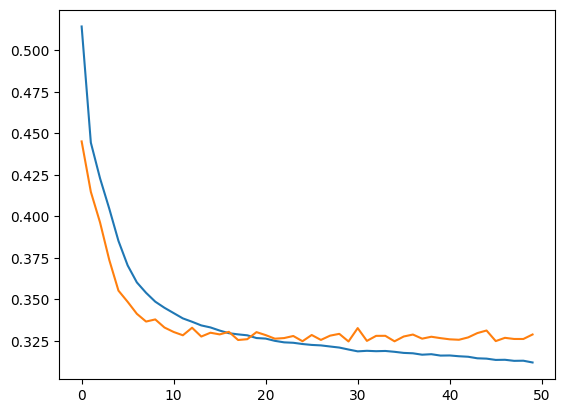

In [207]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

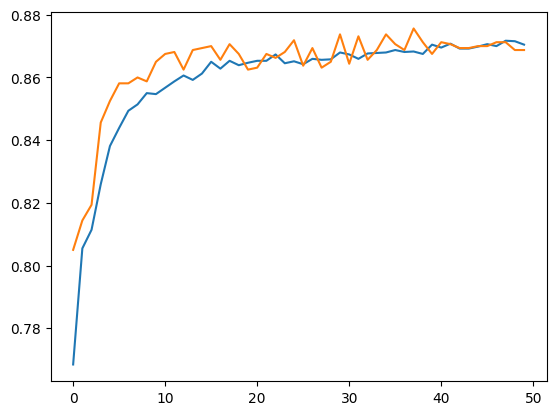

In [208]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
impimsjcsdfhdfdfsfjsfn[]1 \
;limimmmrimslsnfsbgfyu cvhfge8iqpl;sc, mvffwebfqwhshajkcdkvfqvAAAKIHCHACDAbfimporthbgujnnnnnjh                                              